In [1]:
import pandas as pd
import glob

In [2]:
csv_files = glob.glob('api_data_aadhar_biometric/api_data_aadhar_biometric_*.csv') + \
              glob.glob('api_data_aadhar_demographic/api_data_aadhar_demographic_*.csv') + \
              glob.glob('api_data_aadhar_enrolment/api_data_aadhar_enrolment_*.csv')
dfs = []
for file in csv_files:
    try:
        df = pd.read_csv(file)
        df['source_file'] = file # Add a column to identify the source file
        dfs.append(df)
    except Exception as e:
        print(f"Error reading {file}: {e}")

if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    print(f"Successfully combined {len(dfs)} CSV files into a single DataFrame with {len(combined_df)} rows and {len(combined_df.columns)} columns.")
    print("First 5 rows of the combined DataFrame:")
    print(combined_df.head())
else:
    print("No dataframes were loaded. 'combined_df' is not created.")

Successfully combined 12 CSV files into a single DataFrame with 4938837 rows and 12 columns.
First 5 rows of the combined DataFrame:
         date              state      district  pincode  bio_age_5_17  \
0  01-03-2025            Haryana  Mahendragarh   123029         280.0   
1  01-03-2025              Bihar     Madhepura   852121         144.0   
2  01-03-2025  Jammu and Kashmir         Punch   185101         643.0   
3  01-03-2025              Bihar       Bhojpur   802158         256.0   
4  01-03-2025         Tamil Nadu       Madurai   625514         271.0   

   bio_age_17_                                        source_file  \
0        577.0  api_data_aadhar_biometric\api_data_aadhar_biom...   
1        369.0  api_data_aadhar_biometric\api_data_aadhar_biom...   
2       1091.0  api_data_aadhar_biometric\api_data_aadhar_biom...   
3        980.0  api_data_aadhar_biometric\api_data_aadhar_biom...   
4        815.0  api_data_aadhar_biometric\api_data_aadhar_biom...   

   demo_age_5

In [4]:
# 2. Convert the date column in combined_df to datetime objects
combined_df['date'] = pd.to_datetime(combined_df['date'], format='%d-%m-%Y', errors='coerce')

# 3. Sort the combined_df DataFrame first by 'district' and then by 'date'
combined_df = combined_df.sort_values(by=['district', 'date']).reset_index(drop=True)

# 4. Group the sorted combined_df by 'district' and 'date', and then calculate the sum of 'total_activity' for each group. Reset the index.
combined_df['total_activity'] = combined_df[['bio_age_5_17', 'bio_age_17_', 'demo_age_5_17', 'demo_age_17_', 'age_0_5', 'age_5_17', 'age_18_greater']].fillna(0).sum(axis=1)
district_daily_activity = combined_df.groupby(['district', 'date'])['total_activity'].sum().reset_index()
district_daily_activity.rename(columns={'total_activity': 'daily_total_activity'}, inplace=True)

# 5. For each district, calculate the cumulative sum of 'total_activity' and store it in a new column named 'cumulative_coverage'.
district_daily_activity['cumulative_coverage'] = district_daily_activity.groupby('district')['daily_total_activity'].cumsum()

# 6. For each district, calculate the daily growth rate of 'cumulative_coverage' and store it in a new column named 'growth_rate'.
district_daily_activity['growth_rate'] = district_daily_activity.groupby('district')['cumulative_coverage'].pct_change().fillna(0)

print("District-wise daily activity, cumulative coverage, and growth rate calculated:")
print(district_daily_activity.head())


District-wise daily activity, cumulative coverage, and growth rate calculated:
  district       date  daily_total_activity  cumulative_coverage  growth_rate
0   100000 2025-09-02                   3.0                  3.0     0.000000
1   100000 2025-09-03                   1.0                  4.0     0.333333
2   100000 2025-09-08                   1.0                  5.0     0.250000
3   100000 2025-09-09                   1.0                  6.0     0.200000
4   100000 2025-09-11                   2.0                  8.0     0.333333


In [ ]:
import pandas as pd

total_activity_per_district = district_daily_activity.groupby('district')['daily_total_activity'].sum().reset_index()
total_activity_per_district.rename(columns={'daily_total_activity': 'total_activity'}, inplace=True)
latest_cumulative_coverage = district_daily_activity.sort_values(by=['district', 'date']).groupby('district')['cumulative_coverage'].last().reset_index()

# 3. Calculate the average growth rate for each district
average_growth_rate = district_daily_activity.groupby('district')['growth_rate'].mean().reset_index()

print("Total activity per district:")
print(total_activity_per_district.head())
print("\nLatest cumulative coverage per district:")
print(latest_cumulative_coverage.head())
print("\nAverage growth rate per district:")
print(average_growth_rate.head())

Total activity per district:
             district  total_activity
0              100000           220.0
1  24 Paraganas North          6147.0
2  24 Paraganas South           490.0
3           5th cross             1.0
4                   ?             1.0

Latest cumulative coverage per district:
             district  cumulative_coverage
0              100000                220.0
1  24 Paraganas North               6147.0
2  24 Paraganas South                490.0
3           5th cross                  1.0
4                   ?                  1.0

Average growth rate per district:
             district  growth_rate
0              100000     0.399731
1  24 Paraganas North     2.427143
2  24 Paraganas South     0.000000
3           5th cross     0.000000
4                   ?     0.000000


In [6]:
import pandas as pd

# Identify top 10 districts by total activity
top_10_total_activity = total_activity_per_district.sort_values(by='total_activity', ascending=False).head(10)

# Identify top 10 districts by latest cumulative coverage
top_10_cumulative_coverage = latest_cumulative_coverage.sort_values(by='cumulative_coverage', ascending=False).head(10)

# Identify top 10 districts by average growth rate
top_10_growth_rate = average_growth_rate.sort_values(by='growth_rate', ascending=False).head(10)

print("\nTop 10 Districts by Total Activity:")
print(top_10_total_activity)

print("\nTop 10 Districts by Latest Cumulative Coverage:")
print(top_10_cumulative_coverage)

print("\nTop 10 Districts by Average Growth Rate:")
print(top_10_growth_rate)


Top 10 Districts by Total Activity:
              district  total_activity
746               Pune       1076003.0
922              Thane       1062214.0
662             Nashik        845074.0
57          Aurangabad        696335.0
14           Ahmedabad        692504.0
910              Surat        664650.0
387             Jaipur        662370.0
879  South 24 Parganas        659343.0
695   North West Delhi        655325.0
120          Bengaluru        631979.0

Top 10 Districts by Latest Cumulative Coverage:
              district  cumulative_coverage
746               Pune            1076003.0
922              Thane            1062214.0
662             Nashik             845074.0
57          Aurangabad             696335.0
14           Ahmedabad             692504.0
910              Surat             664650.0
387             Jaipur             662370.0
879  South 24 Parganas             659343.0
695   North West Delhi             655325.0
120          Bengaluru             631979.0



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

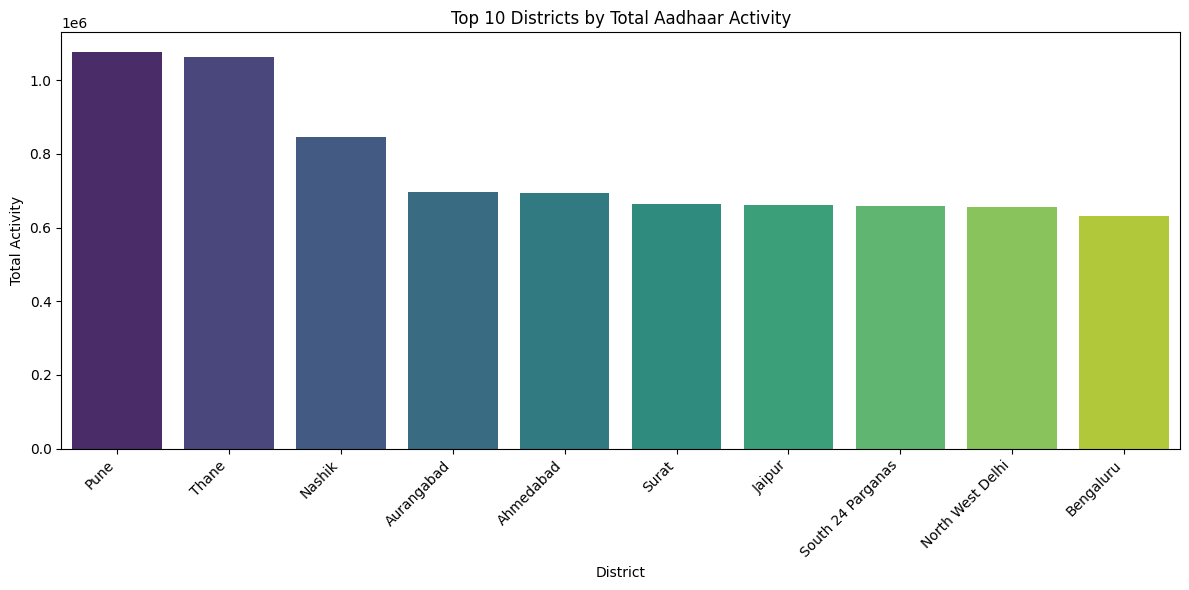

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(x='district', y='total_activity', data=top_10_total_activity, palette='viridis', hue='district', legend=False)
plt.title('Top 10 Districts by Total Aadhaar Activity')
plt.xlabel('District')
plt.ylabel('Total Activity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
top_districts_total_activity_names = top_10_total_activity['district'].tolist()
filtered_total_activity_df = district_daily_activity[district_daily_activity['district'].isin(top_districts_total_activity_names)].copy()

print("Filtered DataFrame for top districts by total activity:")
print(filtered_total_activity_df.head())

Filtered DataFrame for top districts by total activity:
      district       date  daily_total_activity  cumulative_coverage  \
763  Ahmedabad 2025-03-01              112812.0             112812.0   
764  Ahmedabad 2025-04-01               67674.0             180486.0   
765  Ahmedabad 2025-05-01               86280.0             266766.0   
766  Ahmedabad 2025-06-01               67958.0             334724.0   
767  Ahmedabad 2025-07-01               78735.0             413459.0   

     growth_rate  
763     0.000000  
764     0.599883  
765     0.478043  
766     0.254748  
767     0.235224  


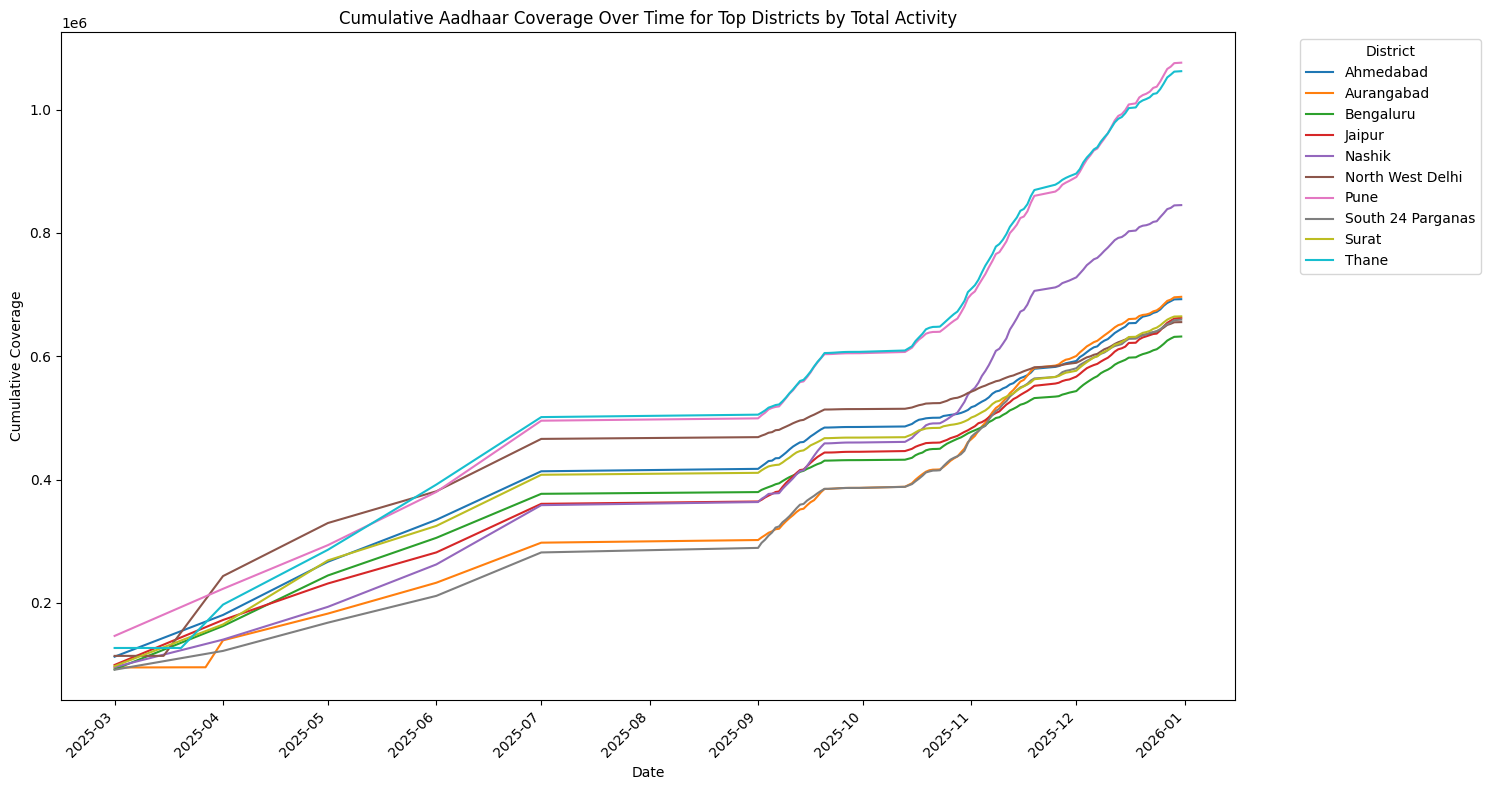

Generated line plot for cumulative coverage over time for top districts by total activity.


In [11]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='date', y='cumulative_coverage', hue='district', data=filtered_total_activity_df)
plt.title('Cumulative Aadhaar Coverage Over Time for Top Districts by Total Activity')
plt.xlabel('Date')
plt.ylabel('Cumulative Coverage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='District', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Generated line plot for cumulative coverage over time for top districts by total activity.")

In [12]:
top_districts_growth_rate_names = top_10_growth_rate['district'].tolist()
filtered_growth_rate_df = district_daily_activity[district_daily_activity['district'].isin(top_districts_growth_rate_names)].copy()

print("Filtered DataFrame for top districts by average growth rate:")
print(filtered_growth_rate_df.head())

Filtered DataFrame for top districts by average growth rate:
                 district       date  daily_total_activity  \
23     24 Paraganas North 2025-06-01                1050.0   
24     24 Paraganas North 2025-07-01                5097.0   
10549     Bengaluru Urban 2025-03-09                 248.0   
10550     Bengaluru Urban 2025-03-20                 484.0   
10551     Bengaluru Urban 2025-06-01               10123.0   

       cumulative_coverage  growth_rate  
23                  1050.0     0.000000  
24                  6147.0     4.854286  
10549                248.0     0.000000  
10550                732.0     1.951613  
10551              10855.0    13.829235  


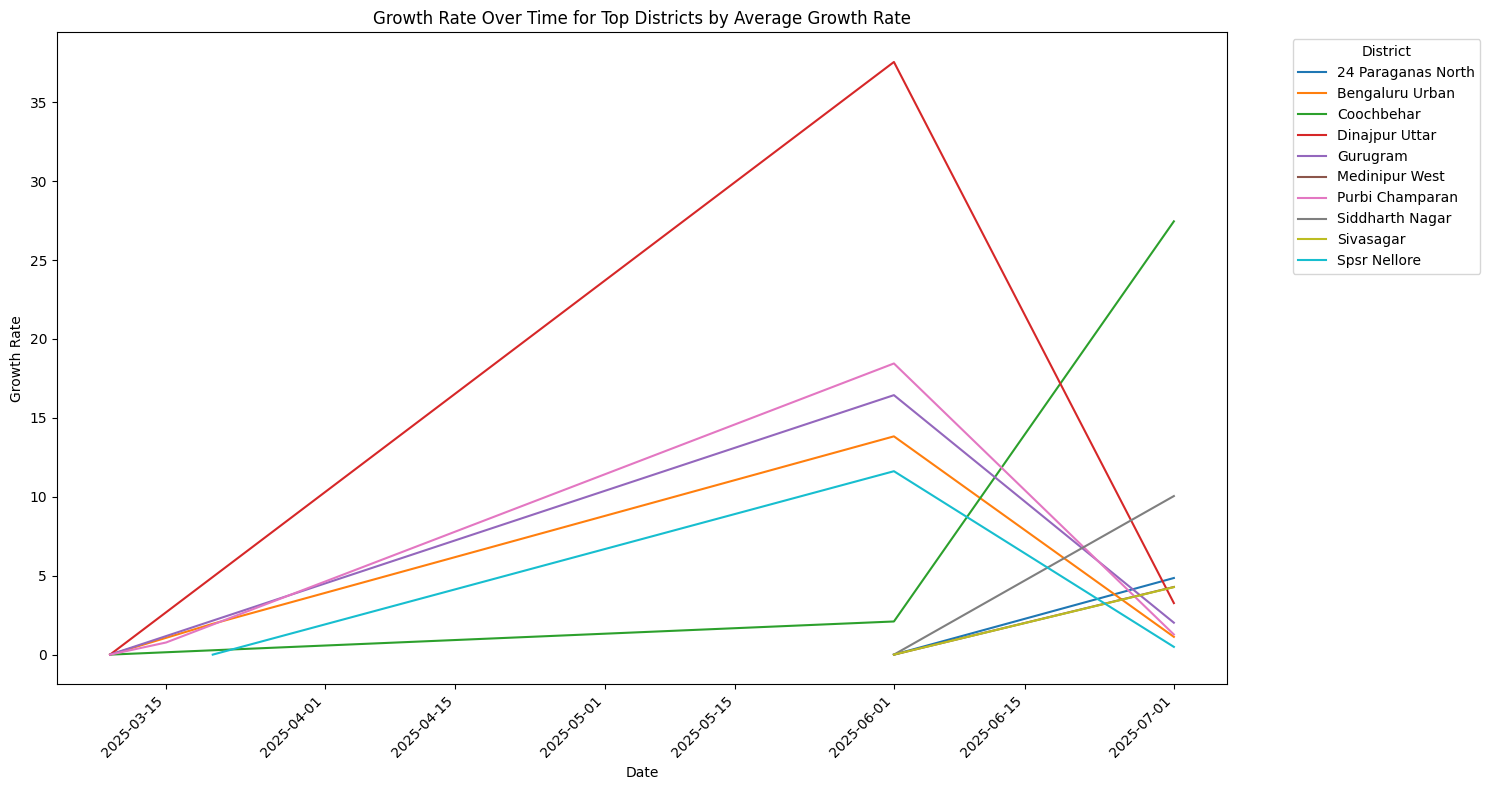

In [13]:
plt.figure(figsize=(15, 8))
sns.lineplot(x='date', y='growth_rate', hue='district', data=filtered_growth_rate_df)
plt.title('Growth Rate Over Time for Top Districts by Average Growth Rate')
plt.xlabel('Date')
plt.ylabel('Growth Rate')
plt.xticks(rotation=45, ha='right')
plt.legend(title='District', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()